#Satellite Image Analysis for Deforestation Monitoring
**Objective:** Detect and monitor deforestation using satellite images (Planet: Understanding the Amazon from Space).

In [1]:
# 📌 Step 1: Install Required Libraries
!pip install rasterio matplotlib numpy pandas scikit-learn torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [2]:
# 📌 Step 2: Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

##Load Planet Dataset (JPEG Images + CSV Labels)

In [3]:
import pandas as pd
from PIL import Image

# 🔄 Replace with your actual path


df = pd.read_csv("train_v2.csv")
print("Loaded", len(df), "images")
df.head()

Loaded 40479 images


,image_name,tags
0,train_0,haze primary
1,train_1,agriculture clear primary water
2,train_2,clear primary
3,train_3,clear primary
4,train_4,agriculture clear habitation primary road


###Encode Tags into Multi-Label Format

In [4]:
all_labels = set(tag for row in df['tags'] for tag in row.split())
label_map = {label: idx for idx, label in enumerate(sorted(all_labels))}

def encode_tags(tags):
    label_vector = np.zeros(len(label_map))
    for tag in tags.split():
        label_vector[label_map[tag]] = 1
    return label_vector

df['encoded_labels'] = df['tags'].apply(encode_tags)

##Load JPEG Images and Use Dataset Class

In [5]:
class SatelliteDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, row['image_name'] + '.jpg')
        image = Image.open(image_path).convert("RGB").resize((128, 128))
        image = np.array(image)
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label = torch.tensor(row['encoded_labels'], dtype=torch.float32)
        return image, label

In [16]:
data_dir = "./planet_data"

##Create Train & Validation DataLoaders

In [17]:
train_df, val_df = train_test_split(df, test_size=0.1)

train_dataset = SatelliteDataset(train_df, data_dir)
val_dataset = SatelliteDataset(val_df, data_dir)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

##Define Dataset Class to Load Satellite Images

In [18]:
class SatelliteDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.image_paths[idx]) as src:
            image = src.read([1, 2, 3])  # RGB bands
        image = np.moveaxis(image, 0, -1)  # Channels last
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

##Define a CNN Model for Land Cover Classification

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 64 * 64, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

##Training and Evaluation Functions

In [11]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Train Loss: {loss.item():.4f}")

##Change Detection (Difference of Predictions Over Time)

In [12]:
def detect_changes(image1, image2):
    diff = np.abs(image2 - image1)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image1)
    plt.title("Before")
    plt.subplot(1, 3, 2)
    plt.imshow(image2)
    plt.title("After")
    plt.subplot(1, 3, 3)
    plt.imshow(diff)
    plt.title("Change Detected")
    plt.show()

##Visualize Satellite Image

In [13]:
def show_image(image_path):
    with rasterio.open(image_path) as src:
        image = src.read([1, 2, 3])
        image = np.moveaxis(image, 0, -1)
        plt.imshow(image)
        plt.title("Satellite Image")
        plt.axis("off")
        plt.show()

##Simulate Image Visualization with Random Data

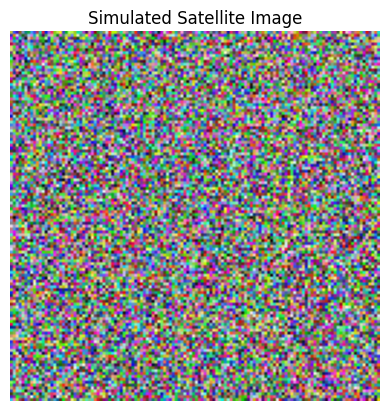

In [14]:
# Generate a random RGB image to simulate a satellite image
def generate_random_image():
    return np.random.randint(0, 255, (128, 128, 3), dtype=np.uint8)

image1 = generate_random_image()
image2 = generate_random_image()

# Show the random image (mock satellite image)
plt.imshow(image1)
plt.title("Simulated Satellite Image")
plt.axis("off")
plt.show()

##Demonstrate Change Detection

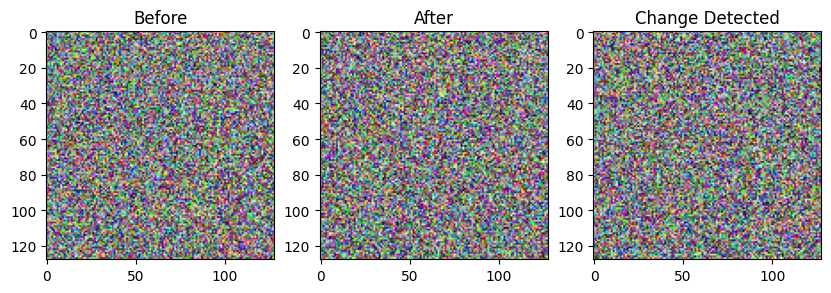

In [15]:
detect_changes(image1, image2)